# Phase 1 — Cadrage

**Projet :** prédiction de résiliation client (churn) — éditeur SaaS B2B
**Certification :** CISIA — Concevoir et implémenter une solution d'intelligence artificielle
**Objet de ce carnet :** rassembler les éléments factuels qui ont **fondé** les décisions de
cadrage, avant toute modélisation.

---

## Pourquoi un carnet séparé pour le cadrage

Le cadrage est la phase où l'on décide *quel problème on résout*. Une erreur commise ici ne
se rattrape pas plus loin : un modèle qui répond parfaitement à la mauvaise question reste
inutile.

Ce carnet est donc **antérieur** à toute modélisation. Il n'entraîne rien, ne prédit rien.
Il établit des faits et en tire des décisions, chacune tracée avec son fondement.

| Livrable | Rôle |
|---|---|
| Ce carnet | Les faits, les figures, les décisions et leur justification |
| `docs/CADRAGE_explications.md` | Les mêmes éléments expliqués sans prérequis technique, avec glossaire |
| `notebooks/cas_usage_churn_saas.ipynb` | Le livrable de certification, dont les sections 2 et 4 reprennent ces conclusions |

**Cinq questions structurent la phase :**

1. Quel est le besoin métier, et à quoi reconnaîtra-t-on que la solution y répond ?
2. Qui est concerné, et qui subit les conséquences ?
3. Quels risques éthiques, quel cadre réglementaire ?
4. À quelles conditions accepte-t-on de mettre la solution en service ?
5. À quelle fréquence remet-on en cause les indicateurs eux-mêmes ?

In [18]:
# --- Environment and data ------------------------------------------------------------
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make the package importable whether or not it is installed: this notebook must be
# replayable straight from an unzipped archive, without running `uv sync`.
RACINE = Path.cwd()
for candidat in [RACINE, *RACINE.parents]:
    if (candidat / "src" / "churn_saas").is_dir():
        RACINE = candidat
        sys.path.insert(0, str(candidat / "src"))
        break

from churn_saas.donnees.ingestion import charger_bronze, inventaire
from churn_saas.donnees.silver import construire_silver
# Guard against a stale local copy of the package: the notebook and `src/` must be in
# sync. Failing here with a clear message beats a bare ImportError further down.
try:
    from churn_saas.notebook import afficher_tableau
except ImportError as erreur:  # pragma: no cover - environment guard
    raise ImportError(
        "`afficher_tableau` est absent de churn_saas.notebook : votre copie locale du "
        "paquet est antérieure au notebook. Remplacez src/churn_saas/ par la version "
        "livrée avec ce carnet, puis relancez le noyau."
    ) from erreur

# Column groups driving the cleaning: numbers stored as text and mixed-format dates
# are deliberate defects of the dataset, handled once here for the whole notebook.

# Full cell content, never an ellipsis: the rationale columns carry the argument.
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})

PALETTE = {"principal": "#2a6f9e", "accent": "#b03030", "neutre": "#8a8a8a",
           "ok": "#2e7d52", "attention": "#c9861a"}

DEC = ["taux_adoption_pct", "heures_usage_30j", "delai_reponse_support_h",
       "revenu_mensuel_recurrent_eur", "valeur_vie_client_eur"]
ENT = ["anciennete_mois", "sieges_souscrits", "utilisateurs_actifs", "connexions_30j",
       "fonctionnalites_total", "fonctionnalites_utilisees", "nb_integrations",
       "derniere_connexion_jours", "tickets_support_90j", "csat",
       "retards_paiement_12m", "sante_compte_fin_periode", "churn"]

brut = charger_bronze(RACINE / "data" / "raw" / "churn_saas_complet.csv")
catalogue = charger_bronze(RACINE / "data" / "raw" / "catalogue_plans.csv")
df = construire_silver(brut, catalogue=catalogue, colonnes_decimales=DEC,
                       colonnes_dates=["date_souscription"], colonnes_entieres=ENT)

print(f"Lignes brutes      : {len(brut):>6}")
print(f"Doublons stricts   : {len(brut) - len(df):>6}")
print(f"Comptes uniques    : {len(df):>6}")
print(f"Colonnes           : {df.shape[1]:>6}  (29 sources + 5 issues du catalogue)")

# --- Full-width table rendering ------------------------------------------------------
# Pandas truncates long strings with an ellipsis. The rationale columns below carry
# the argument, so every cell must show its full content.
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 100)


Lignes brutes      :   5035
Doublons stricts   :     35
Comptes uniques    :   5000
Colonnes           :     34  (29 sources + 5 issues du catalogue)


> **Note de méthode.** Le nettoyage appliqué ici est **exactement** celui du livrable
> principal : les fonctions proviennent du paquet `churn_saas`, elles ne sont pas réécrites.
> Les chiffres de ce carnet et ceux du notebook de certification ne peuvent donc pas diverger.

---

# 1. Cadrer le besoin métier et les critères de succès

## 1.1 Le besoin exprimé

L'éditeur perd des clients à l'échéance de leur contrat. Chaque départ coûte un revenu
récurrent et une part de valeur future. Le besoin formulé : **anticiper les comptes à
risque pour que les équipes Customer Success puissent agir avant l'échéance**.

Trois questions doivent être tranchées avant d'aller plus loin, et les données y répondent.

In [19]:
# --- Question 1: how large is the phenomenon? ---------------------------------------
churn = df["churn"].astype(float)
mrr = df["revenu_mensuel_recurrent_eur"]
clv = df["valeur_vie_client_eur"]

cadrage = pd.DataFrame([
    ("Comptes du portefeuille",            f"{len(df):,}".replace(",", " ")),
    ("Comptes résiliant à l'échéance",     f"{int(churn.sum()):,}".replace(",", " ")),
    ("Taux de résiliation",                f"{churn.mean():.1%}"),
    ("MRR mensuel total",                  f"{mrr.sum():,.0f} €".replace(",", " ")),
    ("MRR porté par les partants",         f"{mrr[churn == 1].sum():,.0f} €".replace(",", " ")),
    ("Part du MRR exposée",                f"{mrr[churn == 1].sum() / mrr.sum():.1%}"),
    ("MRR médian par compte",              f"{mrr.median():,.0f} €".replace(",", " ")),
    ("MRR moyen par compte",               f"{mrr.mean():,.0f} €".replace(",", " ")),
    ("Rapport moyenne / médiane",          f"{mrr.mean() / mrr.median():.1f} ×"),
], columns=["Indicateur de cadrage", "Valeur"])
afficher_tableau(cadrage, "Indicateurs de cadrage établis sur les données")


Indicateur de cadrage,Valeur
Comptes du portefeuille,5 000
Comptes résiliant à l'échéance,1 400
Taux de résiliation,28.0%
MRR mensuel total,17 184 517 €
MRR porté par les partants,3 961 705 €
Part du MRR exposée,23.1%
MRR médian par compte,682 €
MRR moyen par compte,3 543 €
Rapport moyenne / médiane,5.2 ×


**Première lecture, et premier signal d'alerte.** Le MRR moyen vaut plus de cinq fois le
MRR médian. Une distribution où la moyenne s'écarte à ce point de la médiane est fortement
asymétrique : quelques comptes très importants tirent la moyenne vers le haut.

Conséquence immédiate pour le cadrage : **raisonner en « nombre de comptes perdus » serait
trompeur**. Tous les comptes ne pèsent pas le même poids économique. La figure suivante
mesure cette concentration.

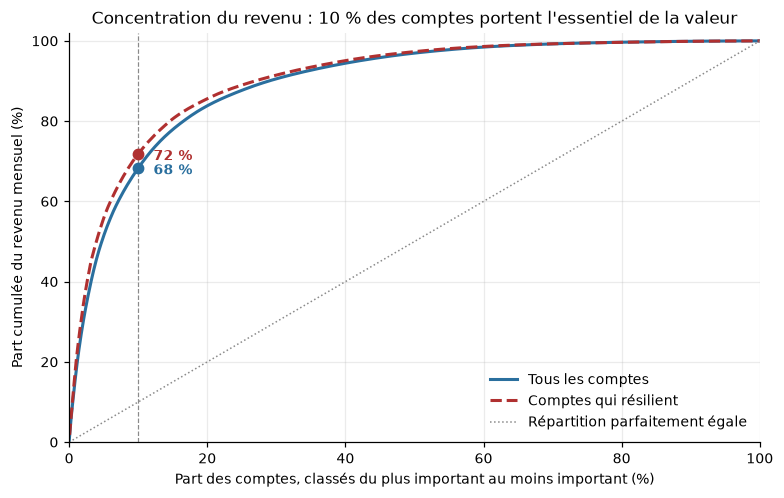

Part des comptes,Part du MRR total,Part du MRR perdu
1 %,17.4%,19.8%
5 %,51.4%,55.8%
10 %,68.3%,71.8%
20 %,83.8%,85.6%
50 %,97.0%,97.3%


In [20]:
# --- Figure 1: value concentration (Lorenz curve) -----------------------------------
def courbe_concentration(serie):
    """Cumulative value share against cumulative account share, sorted descending."""
    v = pd.to_numeric(serie, errors="coerce").dropna().sort_values(ascending=False).to_numpy()
    part_comptes = np.arange(1, len(v) + 1) / len(v)
    part_valeur = np.cumsum(v) / v.sum()
    return part_comptes, part_valeur

x_tous, y_tous = courbe_concentration(mrr)
x_part, y_part = courbe_concentration(mrr[churn == 1])

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(x_tous * 100, y_tous * 100, color=PALETTE["principal"], lw=2,
        label="Tous les comptes")
ax.plot(x_part * 100, y_part * 100, color=PALETTE["accent"], lw=2, ls="--",
        label="Comptes qui résilient")
ax.plot([0, 100], [0, 100], color=PALETTE["neutre"], lw=1, ls=":",
        label="Répartition parfaitement égale")

for x_ref, courbe_x, courbe_y, couleur in [(10, x_tous, y_tous, PALETTE["principal"]),
                                           (10, x_part, y_part, PALETTE["accent"])]:
    y_ref = np.interp(x_ref / 100, courbe_x, courbe_y) * 100
    ax.scatter([x_ref], [y_ref], color=couleur, zorder=5, s=45)
    ax.annotate(f"{y_ref:.0f} %", (x_ref, y_ref), textcoords="offset points",
                xytext=(10, -4), color=couleur, fontweight="bold")

ax.axvline(10, color=PALETTE["neutre"], lw=0.8, ls="--")
ax.set_xlabel("Part des comptes, classés du plus important au moins important (%)")
ax.set_ylabel("Part cumulée du revenu mensuel (%)")
ax.set_title("Concentration du revenu : 10 % des comptes portent l'essentiel de la valeur")
ax.legend(loc="lower right", frameon=False)
ax.set_xlim(0, 100); ax.set_ylim(0, 102)
plt.tight_layout(); plt.show()

concentration = pd.DataFrame(
    [(f"{int(q*100)} %",
      f"{np.interp(q, x_tous, y_tous):.1%}",
      f"{np.interp(q, x_part, y_part):.1%}")
     for q in (0.01, 0.05, 0.10, 0.20, 0.50)],
    columns=["Part des comptes", "Part du MRR total", "Part du MRR perdu"])
afficher_tableau(concentration, "Concentration de la valeur, en part cumulée")


### Décision de cadrage n° 1 — priorisation plutôt que détection exhaustive

**Fait établi :** 10 % des comptes qui résilient portent près des trois quarts du revenu
perdu.

**Décision :** l'objectif n'est pas de détecter *tous* les départs, mais **ceux qui
comptent**. La solution est un outil de priorisation.

**Ce que la décision écarte :** un objectif de rappel maximal. Maximiser le rappel global
reviendrait à traiter avec la même urgence un compte à 200 € et un compte à 180 000 €.

**Trace :** cette décision a été prise *après* l'observation ci-dessus, et non postulée au
départ. Elle constitue l'itération 2 du journal des itérations (Annexe D du livrable
principal) — un retour de l'analyse vers le cadrage.

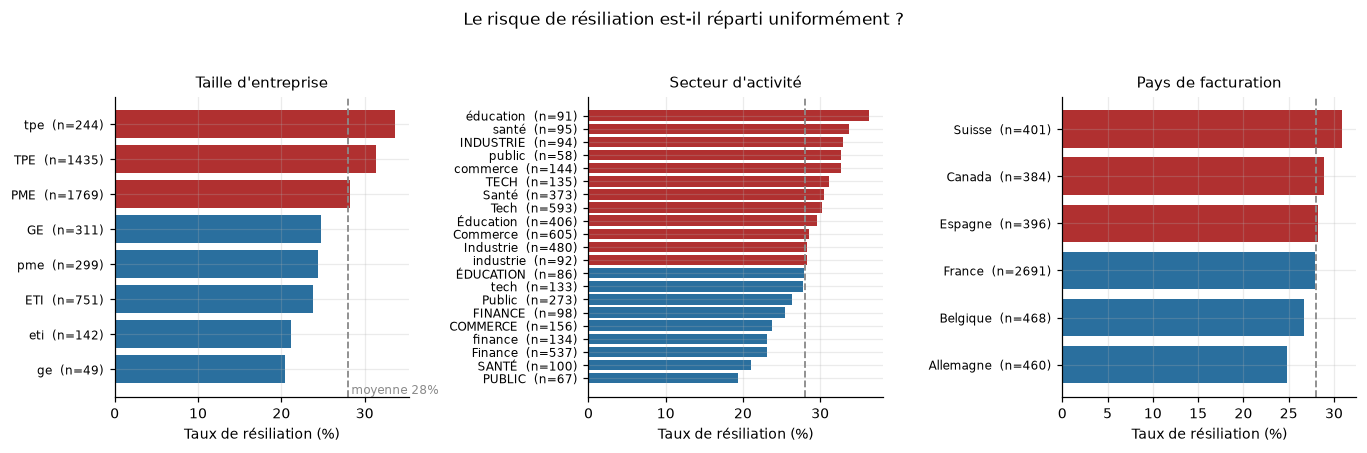

Segment,Taux minimal,Taux maximal,Écart
taille_entreprise,20.4%,33.6%,13.2%
secteur,19.4%,36.3%,16.9%
pays,24.8%,30.9%,6.1%


In [21]:
# --- Question 2: is the risk evenly spread? -----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9))
taux_global = churn.mean()

for ax, colonne, titre in zip(
        axes,
        ["taille_entreprise", "secteur", "pays"],
        ["Taille d'entreprise", "Secteur d'activité", "Pays de facturation"]):
    taux = df.groupby(colonne, dropna=True)["churn"].mean().sort_values()
    effectifs = df.groupby(colonne, dropna=True).size().reindex(taux.index)
    couleurs = [PALETTE["accent"] if t > taux_global else PALETTE["principal"] for t in taux]
    ax.barh(range(len(taux)), taux.to_numpy() * 100, color=couleurs)
    ax.set_yticks(range(len(taux)))
    ax.set_yticklabels([f"{i}  (n={n})" for i, n in zip(taux.index, effectifs)], fontsize=8)
    ax.axvline(taux_global * 100, color=PALETTE["neutre"], ls="--", lw=1.2)
    ax.set_xlabel("Taux de résiliation (%)")
    ax.set_title(titre, fontsize=10)

axes[0].text(taux_global * 100 + 0.4, -0.7, f"moyenne {taux_global:.0%}",
             color=PALETTE["neutre"], fontsize=8)
fig.suptitle("Le risque de résiliation est-il réparti uniformément ?", y=1.04)
plt.tight_layout(); plt.show()

ecarts = pd.DataFrame([
    (col,
     f"{df.groupby(col)['churn'].mean().min():.1%}",
     f"{df.groupby(col)['churn'].mean().max():.1%}",
     f"{df.groupby(col)['churn'].mean().max() - df.groupby(col)['churn'].mean().min():.1%}")
    for col in ["taille_entreprise", "secteur", "pays"]],
    columns=["Segment", "Taux minimal", "Taux maximal", "Écart"])
afficher_tableau(ecarts, "Amplitude du taux de résiliation entre segments")


**Lecture.** Les écarts entre segments restent contenus. Aucun segment ne concentre à lui
seul le risque, ce qui écarte l'hypothèse d'une solution purement segmentée — une règle du
type « surveiller le secteur X » ne suffirait pas.

**Mais ces écarts devront être resurveillés après modélisation.** Un écart modeste dans les
données brutes peut être amplifié par un modèle. C'est l'objet de l'analyse d'équité prévue
en phase d'évaluation, et l'un des engagements pris au titre du cadre éthique (§ 3).

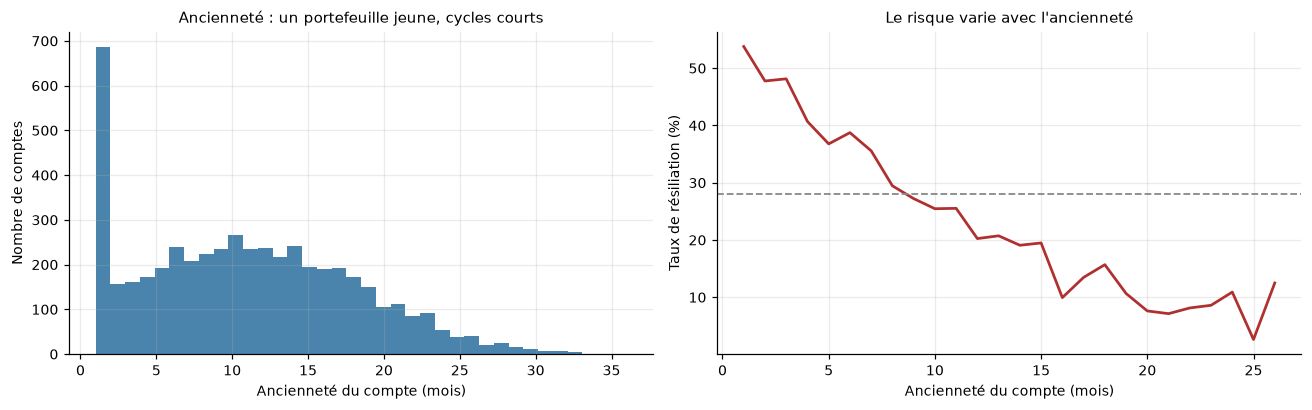

Ancienneté médiane : 10 mois
Ancienneté maximale : 36 mois

Hypothèse de répartition retenue : les 1400 résiliations observées
se répartissent sur ~12 mois, soit ~117 échéances à risque par mois.


In [22]:
# --- Question 3: what action window do we have? -------------------------------------
anciennete = df["anciennete_mois"].astype(float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))

ax1.hist(anciennete.dropna(), bins=36, color=PALETTE["principal"], alpha=0.85)
ax1.set_xlabel("Ancienneté du compte (mois)")
ax1.set_ylabel("Nombre de comptes")
ax1.set_title("Ancienneté : un portefeuille jeune, cycles courts", fontsize=10)

taux_par_anciennete = df.groupby(anciennete.round(0))["churn"].mean() * 100
effectif = df.groupby(anciennete.round(0)).size()
fiable = effectif >= 30
ax2.plot(taux_par_anciennete[fiable].index, taux_par_anciennete[fiable].to_numpy(),
         color=PALETTE["accent"], lw=1.8)
ax2.axhline(taux_global * 100, color=PALETTE["neutre"], ls="--", lw=1.2)
ax2.set_xlabel("Ancienneté du compte (mois)")
ax2.set_ylabel("Taux de résiliation (%)")
ax2.set_title("Le risque varie avec l'ancienneté", fontsize=10)
plt.tight_layout(); plt.show()

print(f"Ancienneté médiane : {anciennete.median():.0f} mois")
print(f"Ancienneté maximale : {anciennete.max():.0f} mois")
print(f"\nHypothèse de répartition retenue : les {int(churn.sum())} résiliations observées")
print(f"se répartissent sur ~12 mois, soit ~{int(churn.sum()) / 12:.0f} échéances à risque par mois.")

### Décision de cadrage n° 2 — cible et fenêtre d'action

**Décision :** la cible est le **churn à l'échéance contractuelle**, et non un départ « à
tout moment ».

**Fondement :** c'est la seule fenêtre où une action de rétention a un sens. Élargir la
cible sans cadrage explicite serait une dérive de périmètre.

**Hypothèse assumée :** le jeu de données est un **instantané**, non un flux. Les 1 400
résiliations observées sont un cumul sur la période couverte, sans horodatage de la
décision. Pour raisonner en volumétrie mensuelle, on suppose une répartition sur douze
mois. Cette hypothèse est explicitée parce qu'elle conditionne le dimensionnement de la
capacité de traitement (§ 4) ; en situation réelle, elle serait remplacée par le calendrier
effectif des échéances.

In [23]:
# --- Success criteria: three levels, three owners -----------------------------------
succes = pd.DataFrame([
    ("Technique", "PR-AUC du modèle retenu",
     "supérieure à la baseline, au-delà de la variabilité entre plis",
     "Validation croisée 5 plis", "Équipe Data"),
    ("Technique", "Stabilité en validation croisée",
     "écart-type faible entre plis", "Validation croisée 5 plis", "Équipe Data"),
    ("Opérationnel", "Volume de comptes signalés",
     "compatible avec la capacité mensuelle de l'équipe", "Comptage sur le lot", "CSM"),
    ("Opérationnel", "Explicabilité du signalement",
     "facteurs restituables pour chaque compte", "Importance + explication locale", "CSM"),
    ("Métier", "Écart de rétention signalés / non signalés",
     "positif et significatif face à un groupe témoin", "Mesure comparative", "Commanditaire"),
    ("Métier", "MRR couvert par la priorisation",
     "part du revenu exposé effectivement atteinte", "Calcul sur le lot", "Commanditaire"),
    ("Conformité", "Aucune variable en fuite ou sensible dans le modèle",
     "contrôle automatisé, zéro alerte", "Contrôle de corrélation", "Équipe Data + DPO"),
], columns=["Niveau", "Critère de succès", "Cible", "Moyen de mesure", "Responsable"])
afficher_tableau(succes, "Critères de succès, par niveau et par responsable")


Niveau,Critère de succès,Cible,Moyen de mesure,Responsable
Technique,PR-AUC du modèle retenu,"supérieure à la baseline, au-delà de la variabilité entre plis",Validation croisée 5 plis,Équipe Data
Technique,Stabilité en validation croisée,écart-type faible entre plis,Validation croisée 5 plis,Équipe Data
Opérationnel,Volume de comptes signalés,compatible avec la capacité mensuelle de l'équipe,Comptage sur le lot,CSM
Opérationnel,Explicabilité du signalement,facteurs restituables pour chaque compte,Importance + explication locale,CSM
Métier,Écart de rétention signalés / non signalés,positif et significatif face à un groupe témoin,Mesure comparative,Commanditaire
Métier,MRR couvert par la priorisation,part du revenu exposé effectivement atteinte,Calcul sur le lot,Commanditaire
Conformité,Aucune variable en fuite ou sensible dans le modèle,"contrôle automatisé, zéro alerte",Contrôle de corrélation,Équipe Data + DPO


**Le critère décisif est le dernier de la famille « Métier ».** Un modèle statistiquement
excellent dont les alertes ne changent rien au taux de rétention ne crée aucune valeur.
C'est ce critère, et non le PR-AUC, qui justifiera le maintien de la solution en service.

Il impose une contrainte que le cadrage doit poser dès maintenant : **un groupe témoin est
nécessaire**. Les comptes signalés étant par construction les plus à risque, comparer leur
rétention à la moyenne du portefeuille produirait une mesure flatteuse et fausse. La
présence de la variable `groupe_experimentation` dans les données suggère qu'un dispositif
de test existe déjà côté métier.

---

# 2. Cartographier les parties prenantes et les impacts

Une solution d'aide à la décision a des effets sur des personnes qui ne l'utilisent pas.
La cartographie distingue donc **ceux qui décident**, **ceux qui utilisent** et **ceux qui
subissent**.

In [24]:
# --- Stakeholders: role, expectation, impact ----------------------------------------
parties = pd.DataFrame([
    ("Direction Customer Success", "Commanditaire", "Décide",
     "Réduire la perte de revenu récurrent",
     "Arbitre la politique de priorisation et le quota réservé aux petits comptes", 5, 4),
    ("Équipes CSM", "Utilisateur", "Utilise",
     "Une liste courte, priorisée et explicable",
     "Leur charge de travail est réorganisée par le score", 3, 5),
    ("DPO / juriste", "Conformité", "Valide",
     "Base légale, durées de conservation, registre à jour",
     "Engage la responsabilité de l'entreprise", 4, 2),
    ("Équipe Data", "Réalisation", "Construit",
     "Un dispositif maintenable et surveillé",
     "Porte la dette technique et le suivi en service", 3, 4),
    ("Équipe technique / infra", "Exploitation", "Exploite",
     "Réutiliser l'ordonnanceur existant, pas de brique nouvelle",
     "Charge d'exploitation du lot mensuel", 2, 3),
    ("Équipe produit", "Contexte", "Informe",
     "Être avertie des dérives liées aux évolutions produit",
     "Ses évolutions modifient la signification des variables d'usage", 2, 2),
    ("Clients à forte valeur", "Concerné", "Subit",
     "Un accompagnement pertinent, non intrusif",
     "Bénéficient prioritairement des actions de rétention", 1, 4),
    ("Clients à faible valeur", "Concerné", "Subit",
     "Ne pas être délaissés",
     "Structurellement moins prioritaires : impact négatif assumé", 1, 5),
], columns=["Partie prenante", "Rôle", "Position", "Attente", "Impact", "Influence", "Exposition"])
afficher_tableau(
    parties[["Partie prenante", "Rôle", "Position", "Attente", "Impact"]],
    "Parties prenantes : rôle, attente et impact subi",
)


Partie prenante,Rôle,Position,Attente,Impact
Direction Customer Success,Commanditaire,Décide,Réduire la perte de revenu récurrent,Arbitre la politique de priorisation et le quota réservé aux petits comptes
Équipes CSM,Utilisateur,Utilise,"Une liste courte, priorisée et explicable",Leur charge de travail est réorganisée par le score
DPO / juriste,Conformité,Valide,"Base légale, durées de conservation, registre à jour",Engage la responsabilité de l'entreprise
Équipe Data,Réalisation,Construit,Un dispositif maintenable et surveillé,Porte la dette technique et le suivi en service
Équipe technique / infra,Exploitation,Exploite,"Réutiliser l'ordonnanceur existant, pas de brique nouvelle",Charge d'exploitation du lot mensuel
Équipe produit,Contexte,Informe,Être avertie des dérives liées aux évolutions produit,Ses évolutions modifient la signification des variables d'usage
Clients à forte valeur,Concerné,Subit,"Un accompagnement pertinent, non intrusif",Bénéficient prioritairement des actions de rétention
Clients à faible valeur,Concerné,Subit,Ne pas être délaissés,Structurellement moins prioritaires : impact négatif assumé


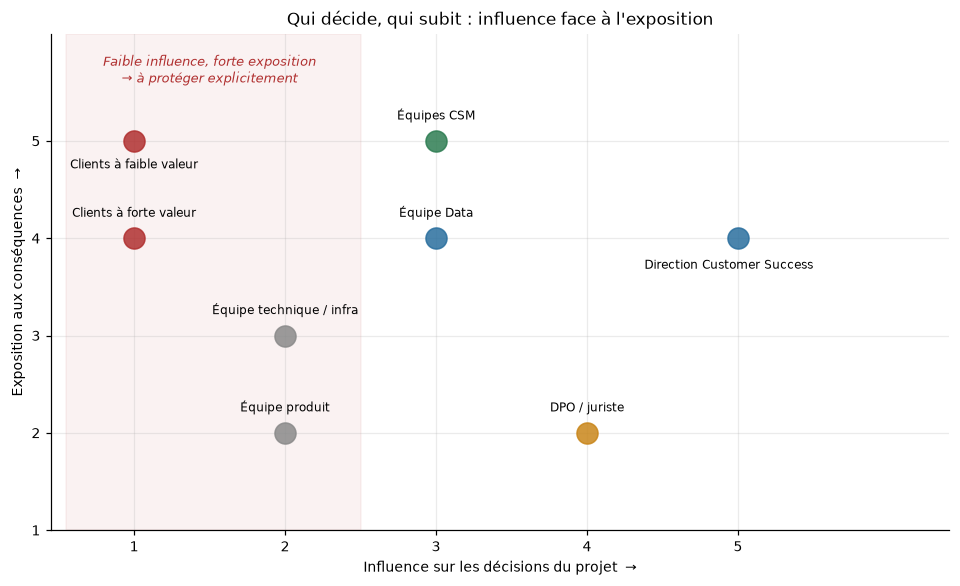

In [25]:
# --- Figure: influence versus exposure matrix ---------------------------------------
fig, ax = plt.subplots(figsize=(8.8, 5.4))
couleur_position = {"Décide": PALETTE["principal"], "Utilise": PALETTE["ok"],
                    "Valide": PALETTE["attention"], "Construit": PALETTE["principal"],
                    "Exploite": PALETTE["neutre"], "Informe": PALETTE["neutre"],
                    "Subit": PALETTE["accent"]}

decalages = {"Équipe Data": (0, 14), "Direction Customer Success": (-6, -20),
             "Clients à forte valeur": (0, 14), "Clients à faible valeur": (0, -18)}

for ligne in parties.itertuples():
    ax.scatter(ligne.Influence, ligne.Exposition, s=190,
               color=couleur_position[ligne.Position], alpha=0.85, zorder=3)
    dx, dy = decalages.get(ligne._1, (0, 14))
    ax.annotate(ligne._1, (ligne.Influence, ligne.Exposition), fontsize=8,
                ha="center", textcoords="offset points", xytext=(dx, dy))

ax.axvspan(0.55, 2.5, color=PALETTE["accent"], alpha=0.06)
ax.text(1.5, 5.6, "Faible influence, forte exposition\n→ à protéger explicitement",
        ha="center", fontsize=8.5, color=PALETTE["accent"], style="italic")
ax.set_xlabel("Influence sur les décisions du projet  →")
ax.set_ylabel("Exposition aux conséquences  →")
ax.set_xlim(0.45, 6.4); ax.set_ylim(1.2, 6.1)
ax.set_xticks(range(1, 6)); ax.set_yticks(range(1, 6))
ax.set_title("Qui décide, qui subit : influence face à l'exposition")
plt.tight_layout(); plt.show()

### Lecture de la matrice — le quadrant qui compte

Le quadrant en bas à droite est vide, et c'est heureux : personne n'a une forte influence
sans exposition.

**Le quadrant critique est celui de gauche**, faible influence et forte exposition. On y
trouve les clients à faible valeur : ils subissent pleinement les conséquences de la
priorisation sans avoir voix au chapitre. C'est la définition même d'un risque éthique, et
cela justifie les mesures compensatoires du paragraphe suivant.

Les équipes CSM occupent une position intermédiaire souvent négligée : leur charge de
travail est réorganisée par un dispositif qu'elles ne décident pas. D'où l'obligation de
transparence retenue au § 3 — elles doivent savoir qu'un score algorithmique intervient.

---

# 3. Risques éthiques et cadre réglementaire

## 3.1 Les cadres applicables, et leur application concrète

Citer un règlement ne suffit pas. Le tableau ci-dessous associe à chaque cadre **la
disposition précise** invoquée, **ce qu'elle change concrètement** dans le projet, et
**où la preuve se trouve** dans le livrable.

Deux lignes méritent d'être remarquées. La classification du système en **risque minimal**
au titre de l'AI Act n'est pas une échappatoire : elle est argumentée par élimination des
catégories à haut risque de l'annexe III. Et l'obligation de **transparence envers les CSM**
est retenue alors que le règlement ne l'impose pas à ce niveau de risque — la supervision
humaine n'est effective que si l'utilisateur sait qu'un algorithme intervient.

In [26]:
# --- Applicable frameworks: obligation, concrete application, where it is evidenced ---
# Naming a regulation proves nothing. Each row therefore states what the framework
# requires, what it changes in this project, and where that change can be checked.
cadres = pd.DataFrame(
    [
        (
            "RGPD — règlement (UE) 2016/679",
            "Art. 6.1.f — base légale du traitement",
            "Intérêt légitime de l'éditeur à préserver sa relation client. Pas de "
            "consentement requis, mais un droit d'opposition à prévoir.",
            "Section 3 — gouvernance",
        ),
        (
            "RGPD",
            "Art. 5.1.c — minimisation des données",
            "`commentaire_csm` (texte libre, peut désigner des personnes) et `client_id` "
            "sont exclus de la matrice de variables explicatives.",
            "Section 7 — préparation",
        ),
        (
            "RGPD",
            "Art. 5.1.e — limitation de conservation",
            "Cycle de vie documenté de la collecte à la purge. La durée de conservation "
            "des scores reste ouverte : le suivi de dérive demande de la profondeur, la "
            "minimisation demande l'inverse. Arbitrage porté au DPO.",
            "Section 3 — cycle de vie",
        ),
        (
            "RGPD",
            "Art. 30 — registre des traitements",
            "Nouveau traitement à inscrire au registre avant mise en service. "
            "Action portée au DPO, non réalisable par l'équipe technique.",
            "Point ouvert — § 6.2",
        ),
        (
            "AI Act — règlement (UE) 2024/1689",
            "Art. 6 et annexe III — classification du système",
            "Risque minimal. Le système n'entre dans aucune catégorie à haut risque : ni "
            "évaluation de solvabilité, ni usage en ressources humaines, ni notation "
            "sociale, ni accès à un service essentiel. Aucune obligation renforcée.",
            "Section 4 — conformité",
        ),
        (
            "AI Act",
            "Art. 50 — transparence (retenue volontairement)",
            "Non imposée pour un système à risque minimal, mais retenue : les CSM sont "
            "informés qu'un score algorithmique alimente leur priorisation. La "
            "supervision humaine n'est effective que si l'utilisateur sait qu'un "
            "algorithme intervient.",
            "Section 10 — exploitation",
        ),
        (
            "Lignes directrices UE — IA digne de confiance",
            "Exigence 1 — action et contrôle humains",
            "Aucune décision automatisée. Le modèle classe, le CSM décide, et il reste "
            "libre de ne pas agir sur un compte signalé.",
            "Sections 4 et 10",
        ),
        (
            "Lignes directrices UE",
            "Exigence 4 — transparence et explicabilité",
            "Modèles interprétables privilégiés ; les empilements opaques sont écartés. "
            "Une explication par compte est exigée, pas seulement une importance globale.",
            "Sections 8 et 9",
        ),
        (
            "Lignes directrices UE",
            "Exigence 5 — diversité et non-discrimination",
            "Taux de résiliation contrôlé par secteur, pays et taille d'entreprise avant "
            "modélisation, puis analyse d'équité après modélisation.",
            "Sections 4 et 12",
        ),
        (
            "CNIL — recommandations IA",
            "Analyse d'impact (AIPD)",
            "Non obligatoire ici : aucune donnée sensible au sens de l'art. 9, aucune "
            "décision produisant des effets juridiques. Position à documenter plutôt "
            "qu'à supposer.",
            "Section 4 — conformité",
        ),
        (
            "CNIL",
            "Sécurité et traçabilité",
            "Chaque score est stocké avec la version du modèle qui l'a produit : une "
            "décision passée reste explicable a posteriori.",
            "Section 10 — versioning",
        ),
    ],
    columns=["Cadre", "Disposition", "Application concrète au projet", "Où c'est traité"],
)
afficher_tableau(cadres, "Cadres applicables et traduction concrète dans le projet")


Cadre,Disposition,Application concrète au projet,Où c'est traité
RGPD — règlement (UE) 2016/679,Art. 6.1.f — base légale du traitement,"Intérêt légitime de l'éditeur à préserver sa relation client. Pas de consentement requis, mais un droit d'opposition à prévoir.",Section 3 — gouvernance
RGPD,Art. 5.1.c — minimisation des données,"`commentaire_csm` (texte libre, peut désigner des personnes) et `client_id` sont exclus de la matrice de variables explicatives.",Section 7 — préparation
RGPD,Art. 5.1.e — limitation de conservation,"Cycle de vie documenté de la collecte à la purge. La durée de conservation des scores reste ouverte : le suivi de dérive demande de la profondeur, la minimisation demande l'inverse. Arbitrage porté au DPO.",Section 3 — cycle de vie
RGPD,Art. 30 — registre des traitements,"Nouveau traitement à inscrire au registre avant mise en service. Action portée au DPO, non réalisable par l'équipe technique.",Point ouvert — § 6.2
AI Act — règlement (UE) 2024/1689,Art. 6 et annexe III — classification du système,"Risque minimal. Le système n'entre dans aucune catégorie à haut risque : ni évaluation de solvabilité, ni usage en ressources humaines, ni notation sociale, ni accès à un service essentiel. Aucune obligation renforcée.",Section 4 — conformité
AI Act,Art. 50 — transparence (retenue volontairement),"Non imposée pour un système à risque minimal, mais retenue : les CSM sont informés qu'un score algorithmique alimente leur priorisation. La supervision humaine n'est effective que si l'utilisateur sait qu'un algorithme intervient.",Section 10 — exploitation
Lignes directrices UE — IA digne de confiance,Exigence 1 — action et contrôle humains,"Aucune décision automatisée. Le modèle classe, le CSM décide, et il reste libre de ne pas agir sur un compte signalé.",Sections 4 et 10
Lignes directrices UE,Exigence 4 — transparence et explicabilité,"Modèles interprétables privilégiés ; les empilements opaques sont écartés. Une explication par compte est exigée, pas seulement une importance globale.",Sections 8 et 9
Lignes directrices UE,Exigence 5 — diversité et non-discrimination,"Taux de résiliation contrôlé par secteur, pays et taille d'entreprise avant modélisation, puis analyse d'équité après modélisation.",Sections 4 et 12
CNIL — recommandations IA,Analyse d'impact (AIPD),"Non obligatoire ici : aucune donnée sensible au sens de l'art. 9, aucune décision produisant des effets juridiques. Position à documenter plutôt qu'à supposer.",Section 4 — conformité


In [27]:
# --- Excluded variables: distinct, non-interchangeable rationales -------------------
from churn_saas.donnees.gold import table_exclusions

exclusions = table_exclusions()
exclusions["Nature du motif"] = exclusions["motif d'exclusion"].str.split(" —").str[0]
exclusions.columns = ["Variable", "Motif détaillé", "Nature"]
afficher_tableau(
    exclusions[["Variable", "Nature", "Motif détaillé"]],
    "Variables écartées et motif propre à chacune",
)


Variable,Nature,Motif détaillé
client_id,identifiant,"identifiant — aucun pouvoir prédictif, risque de mémorisation"
commentaire_csm,RGPD,RGPD — texte libre susceptible de contenir des données personnelles
groupe_experimentation,artefact de process interne,artefact de process interne — pas une variable métier
sante_compte_fin_periode,fuite temporelle,fuite temporelle — information postérieure à la décision
valeur_vie_client_eur,cible secondaire,"cible secondaire — pondération de décision, jamais variable explicative"


**Pourquoi la distinction des motifs compte.** Le référentiel sépare la compétence éthique
(C2) de la préparation technique (C3). Justifier toutes ces exclusions par « ça dégrade le
modèle » serait un argument statistique, insuffisant pour C2.

`commentaire_csm` est écartée parce qu'elle peut contenir des données personnelles, pas
parce qu'elle serait inutile. `sante_compte_fin_periode` est écartée parce qu'elle est
postérieure à la décision, pas parce qu'elle serait sensible. Ces motifs ne sont pas
interchangeables.

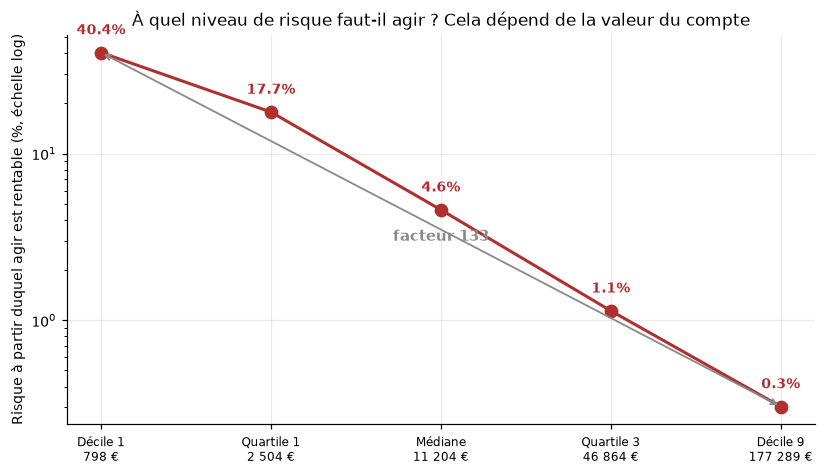

Position,Valeur vie client,Coût d'un départ non détecté,Rapport au coût d'un contact inutile,Seuil d'action rationnel
Décile 1,798 €,199 €,1.5 ×,40.4%
Quartile 1,2 504 €,626 €,4.6 ×,17.7%
Médiane,11 204 €,2 801 €,20.7 ×,4.6%
Quartile 3,46 864 €,11 716 €,86.8 ×,1.1%
Décile 9,177 289 €,44 322 €,328.3 ×,0.3%


In [28]:
# --- The finding that created the main ethical dilemma ------------------------------
U_RETENTION, COUT_FP = 0.25, 135.0
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]
valeurs = clv.quantile(quantiles)
cout_fn = valeurs * U_RETENTION
seuils = COUT_FP / (COUT_FP + cout_fn)

fig, ax = plt.subplots(figsize=(7.6, 4.4))
positions = range(len(quantiles))
ax.plot(positions, seuils.to_numpy() * 100, "o-", color=PALETTE["accent"], lw=2, ms=8)
for p, s, v in zip(positions, seuils, valeurs):
    ax.annotate(f"{s:.1%}", (p, s * 100), textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=9, fontweight="bold", color=PALETTE["accent"])
ax.set_yscale("log")
ax.set_xticks(list(positions))
ax.set_xticklabels([f"Décile 1\n{valeurs.iloc[0]:,.0f} €".replace(",", " "),
                    f"Quartile 1\n{valeurs.iloc[1]:,.0f} €".replace(",", " "),
                    f"Médiane\n{valeurs.iloc[2]:,.0f} €".replace(",", " "),
                    f"Quartile 3\n{valeurs.iloc[3]:,.0f} €".replace(",", " "),
                    f"Décile 9\n{valeurs.iloc[4]:,.0f} €".replace(",", " ")], fontsize=8)
ax.set_ylabel("Risque à partir duquel agir est rentable (%, échelle log)")
ax.set_title("À quel niveau de risque faut-il agir ? Cela dépend de la valeur du compte")
ax.annotate("", xy=(0, seuils.iloc[0] * 100), xytext=(4, seuils.iloc[-1] * 100),
            arrowprops=dict(arrowstyle="<->", color=PALETTE["neutre"], lw=1.2))
ax.text(2, 3, f"facteur {seuils.iloc[0] / seuils.iloc[-1]:.0f}", ha="center",
        fontsize=10, fontweight="bold", color=PALETTE["neutre"])
plt.tight_layout(); plt.show()

afficher_tableau(pd.DataFrame({
    "Position": ["Décile 1", "Quartile 1", "Médiane", "Quartile 3", "Décile 9"],
    "Valeur vie client": [f"{v:,.0f} €".replace(",", " ") for v in valeurs],
    "Coût d'un départ non détecté": [f"{c:,.0f} €".replace(",", " ") for c in cout_fn],
    "Rapport au coût d'un contact inutile": [f"{c / COUT_FP:.1f} ×" for c in cout_fn],
    "Seuil d'action rationnel": [f"{s:.1%}" for s in seuils],
}), "Seuil d'action rationnel selon la valeur du compte")

### Le dilemme que ce graphique impose

Pour un compte du dernier décile, il devient rentable d'agir dès **0,3 %** de risque. Pour
un compte du premier décile, il faut atteindre **40 %**. Un facteur supérieur à cent.

**Ce que cela implique, et qu'il serait malhonnête de taire :** à risque égal, un petit
compte ne sera pratiquement jamais contacté.

Ce n'est **pas une discrimination au sens juridique** — la valeur d'un client est un
critère commercial légitime, sans lien avec une caractéristique protégée. Mais c'est un
arbitrage à exposer, pour trois raisons :

1. **Effet d'auto-réalisation.** Les petits comptes délaissés résilient davantage, ce qui
   abaisse leur valeur estimée au cycle suivant, ce qui les délaisse encore plus.
2. **Tension avec un engagement commercial** d'égalité de traitement, si l'entreprise en a pris un.
3. **Angle mort de mesure.** Le portefeuille de petits comptes peut se dégrader sans qu'un
   indicateur global pondéré par la valeur ne le signale.

In [29]:
dilemmes = pd.DataFrame([
    ("Contacter un compte à risque peut précipiter son départ",
     "Une sollicitation inhabituelle signale au client qu'il est considéré comme partant, "
     "et peut déclencher une réflexion qu'il n'avait pas engagée",
     "Le score déclenche une action de valeur (accompagnement, revue d'usage), "
     "jamais un geste commercial défensif immédiat. Le CSM reste libre de ne pas agir",
     "Commanditaire + CSM"),
    ("Prioriser par la valeur délaisse les petits comptes",
     "Le seuil d'action rationnel varie d'un facteur supérieur à 100 entre déciles",
     "Arbitrage assumé comme décision commerciale, compensé par un quota réservé, "
     "un suivi par segment et des actions à faible coût unitaire",
     "Commanditaire"),
], columns=["Dilemme", "Pourquoi c'en est un", "Position retenue", "Qui arbitre"])

mesures = pd.DataFrame([
    ("Quota réservé", "Une part du volume mensuel est allouée hors priorisation par valeur"),
    ("Suivi par segment", "Le taux de rétention est suivi par taille d'entreprise, pas seulement en agrégat"),
    ("Traitement différencié", "Les petits comptes relèvent d'actions de masse à faible coût unitaire"),
    ("Arbitrage explicite", "La pondération valeur / volume est validée par le commanditaire, pas fixée par l'équipe technique"),
], columns=["Mesure de limitation", "Modalité"])

print("DILEMMES IDENTIFIÉS\n")
afficher_tableau(dilemmes, "Dilemmes éthiques identifiés et position retenue")
print("\nMESURES DE LIMITATION RETENUES\n")
afficher_tableau(mesures, "Mesures de limitation retenues")

DILEMMES IDENTIFIÉS



Dilemme,Pourquoi c'en est un,Position retenue,Qui arbitre
Contacter un compte à risque peut précipiter son départ,"Une sollicitation inhabituelle signale au client qu'il est considéré comme partant, et peut déclencher une réflexion qu'il n'avait pas engagée","Le score déclenche une action de valeur (accompagnement, revue d'usage), jamais un geste commercial défensif immédiat. Le CSM reste libre de ne pas agir",Commanditaire + CSM
Prioriser par la valeur délaisse les petits comptes,Le seuil d'action rationnel varie d'un facteur supérieur à 100 entre déciles,"Arbitrage assumé comme décision commerciale, compensé par un quota réservé, un suivi par segment et des actions à faible coût unitaire",Commanditaire



MESURES DE LIMITATION RETENUES



Mesure de limitation,Modalité
Quota réservé,Une part du volume mensuel est allouée hors priorisation par valeur
Suivi par segment,"Le taux de rétention est suivi par taille d'entreprise, pas seulement en agrégat"
Traitement différencié,Les petits comptes relèvent d'actions de masse à faible coût unitaire
Arbitrage explicite,"La pondération valeur / volume est validée par le commanditaire, pas fixée par l'équipe technique"


**Décision de principe :** l'effet n'est **pas corrigé dans le modèle** mais dans la
politique d'action. Altérer le score pour le rendre « équitable » masquerait l'arbitrage au
lieu de l'exposer. La correction relève de la décision métier, pas de l'algorithme.

---

# 4. Critères d'acceptation

Les critères de succès (§ 1) disent ce qu'on cherche à obtenir. Les **critères
d'acceptation** disent à quelles conditions on accepte de mettre la solution en service.
La différence est qu'ils sont **bloquants** : un seul non satisfait interdit le passage en
production.

Ils sont présentés ci-dessous sous forme de **carte de contrôle**, pour être lisibles d'un
seul regard — en revue de projet comme en soutenance.

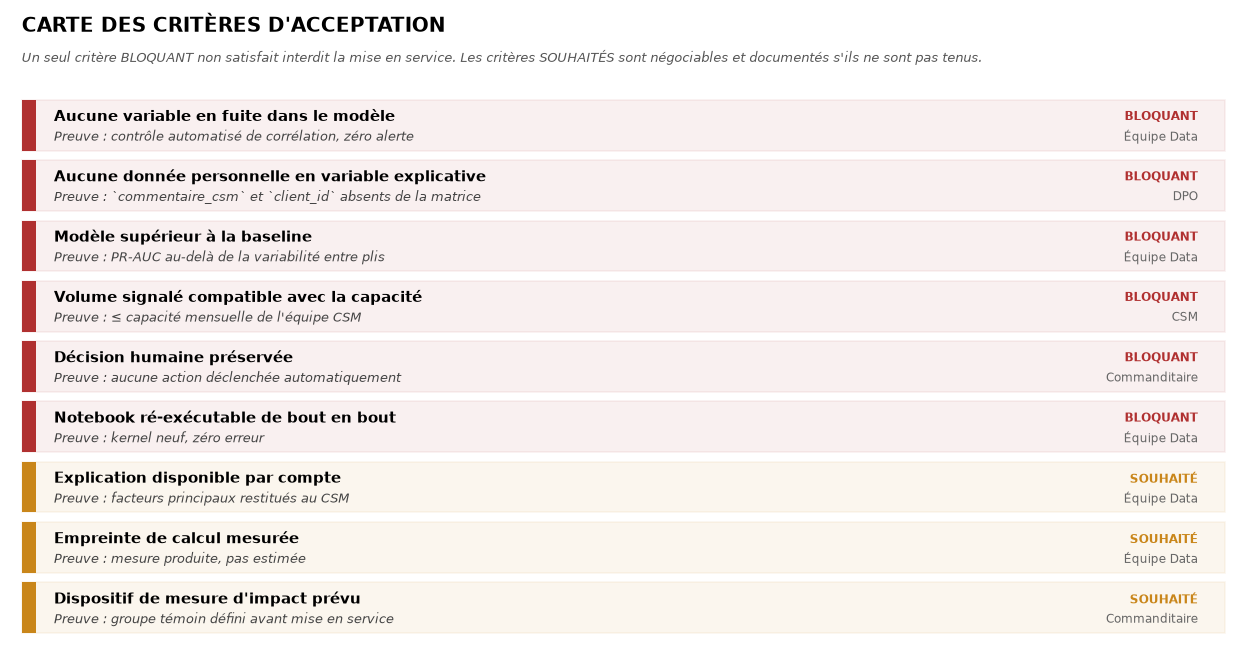

In [30]:
# --- Signature figure: acceptance criteria control card -----------------------------
criteres = [
    ("BLOQUANT", "Aucune variable en fuite dans le modèle",
     "contrôle automatisé de corrélation, zéro alerte", "Équipe Data"),
    ("BLOQUANT", "Aucune donnée personnelle en variable explicative",
     "`commentaire_csm` et `client_id` absents de la matrice", "DPO"),
    ("BLOQUANT", "Modèle supérieur à la baseline",
     "PR-AUC au-delà de la variabilité entre plis", "Équipe Data"),
    ("BLOQUANT", "Volume signalé compatible avec la capacité",
     "≤ capacité mensuelle de l'équipe CSM", "CSM"),
    ("BLOQUANT", "Décision humaine préservée",
     "aucune action déclenchée automatiquement", "Commanditaire"),
    ("BLOQUANT", "Notebook ré-exécutable de bout en bout",
     "kernel neuf, zéro erreur", "Équipe Data"),
    ("SOUHAITÉ", "Explication disponible par compte",
     "facteurs principaux restitués au CSM", "Équipe Data"),
    ("SOUHAITÉ", "Empreinte de calcul mesurée",
     "mesure produite, pas estimée", "Équipe Data"),
    ("SOUHAITÉ", "Dispositif de mesure d'impact prévu",
     "groupe témoin défini avant mise en service", "Commanditaire"),
]

fig, ax = plt.subplots(figsize=(11.4, 6.1))
ax.axis("off")
y = len(criteres)
for niveau, critere, preuve, responsable in criteres:
    bloquant = niveau == "BLOQUANT"
    couleur = PALETTE["accent"] if bloquant else PALETTE["attention"]
    ax.add_patch(plt.Rectangle((0, y - 0.42), 11.2, 0.84, facecolor=couleur,
                               alpha=0.07, edgecolor=couleur, lw=1.1))
    ax.add_patch(plt.Rectangle((0, y - 0.42), 0.13, 0.84, facecolor=couleur, lw=0))
    ax.text(0.30, y + 0.14, critere, fontsize=10, fontweight="bold", va="center")
    ax.text(0.30, y - 0.19, f"Preuve : {preuve}", fontsize=8.3, va="center",
            color="#444444", style="italic")
    ax.text(10.95, y + 0.14, niveau, fontsize=8, fontweight="bold",
            va="center", ha="right", color=couleur)
    ax.text(10.95, y - 0.19, responsable, fontsize=8, va="center", ha="right", color="#666666")
    y -= 1

ax.set_xlim(-0.1, 11.3); ax.set_ylim(0.3, len(criteres) + 1.9)
ax.text(0, len(criteres) + 1.55, "CARTE DES CRITÈRES D'ACCEPTATION",
        fontsize=13, fontweight="bold")
ax.text(0, len(criteres) + 1.05,
        "Un seul critère BLOQUANT non satisfait interdit la mise en service. "
        "Les critères SOUHAITÉS sont négociables et documentés s'ils ne sont pas tenus.",
        fontsize=8.5, color="#555555", style="italic")
plt.tight_layout(); plt.show()

### Pourquoi distinguer bloquant et souhaité

Un critère d'acceptation qui se négocie n'est pas un critère d'acceptation. En marquant six
critères comme **bloquants**, on accepte par avance de renoncer à la mise en service si
l'un d'eux n'est pas satisfait — y compris sous pression de calendrier.

Les trois critères **souhaités** peuvent ne pas être tenus, à condition que le manque soit
documenté et porté au commanditaire. Cette distinction est plus honnête qu'une liste
uniforme que l'on rognerait discrètement le moment venu.

**Le sixième critère bloquant surprend souvent** : un notebook qui ne se ré-exécute pas de
bout en bout ne prouve rien. Un résultat non reproductible n'est pas un résultat.

---

# 5. Périodicité de révision des indicateurs

Une distinction est nécessaire, et elle est rarement faite :

| | Question posée | Exemple |
|---|---|---|
| **Fréquence de mesure** | L'indicateur a-t-il bougé ? | Calculer le PSI chaque mois |
| **Fréquence de révision** | L'indicateur est-il encore le bon ? | Ce seuil de 0,25 a-t-il encore un sens ? |

La seconde est presque toujours oubliée. Un dispositif de suivi conçu à la mise en service
et jamais remis en cause devient progressivement aveugle : les seuils calibrés sur un
contexte cessent de correspondre au contexte suivant.

Cette périodicité est fixée **dès le cadrage**, et non en phase de suivi — c'est une
exigence explicite du référentiel (C9).

In [31]:
suivi = pd.DataFrame([
    ("Technique", "PR-AUC en production", "Mensuelle", "Trimestrielle", "Équipe Data",
     "baisse > 15 % vs référence"),
    ("Technique", "Rappel au point de fonctionnement", "Mensuelle", "Trimestrielle",
     "Équipe Data + CSM", "< cible métier"),
    ("Dérive", "PSI sur variables clés", "Mensuelle", "Trimestrielle", "Équipe Data", "> 0,25"),
    ("Qualité", "Taux de manquants à l'entrée", "À chaque lot", "Semestrielle",
     "Pipeline (automatique)", "> 10 % sur une variable clé"),
    ("Volumétrie", "Comptes signalés", "Mensuelle", "Trimestrielle", "Équipe Data",
     "écart > 30 % vs mois précédent"),
    ("Métier", "Rétention signalés vs témoin", "Trimestrielle", "Annuelle", "Commanditaire",
     "non significative"),
    ("Métier", "Retours de faux positifs CSM", "Continue", "Trimestrielle", "CSM + Data",
     "volume anormal"),
    ("Éthique", "Rétention par segment de taille", "Trimestrielle", "Annuelle",
     "Commanditaire + DPO", "écart croissant entre segments"),
], columns=["Famille", "Indicateur", "Fréquence de mesure", "Fréquence de révision",
            "Responsable", "Seuil d'alerte"])
afficher_tableau(suivi, "Indicateurs : fréquence de mesure, fréquence de révision, responsable")


Famille,Indicateur,Fréquence de mesure,Fréquence de révision,Responsable,Seuil d'alerte
Technique,PR-AUC en production,Mensuelle,Trimestrielle,Équipe Data,baisse > 15 % vs référence
Technique,Rappel au point de fonctionnement,Mensuelle,Trimestrielle,Équipe Data + CSM,< cible métier
Dérive,PSI sur variables clés,Mensuelle,Trimestrielle,Équipe Data,"> 0,25"
Qualité,Taux de manquants à l'entrée,À chaque lot,Semestrielle,Pipeline (automatique),> 10 % sur une variable clé
Volumétrie,Comptes signalés,Mensuelle,Trimestrielle,Équipe Data,écart > 30 % vs mois précédent
Métier,Rétention signalés vs témoin,Trimestrielle,Annuelle,Commanditaire,non significative
Métier,Retours de faux positifs CSM,Continue,Trimestrielle,CSM + Data,volume anormal
Éthique,Rétention par segment de taille,Trimestrielle,Annuelle,Commanditaire + DPO,écart croissant entre segments


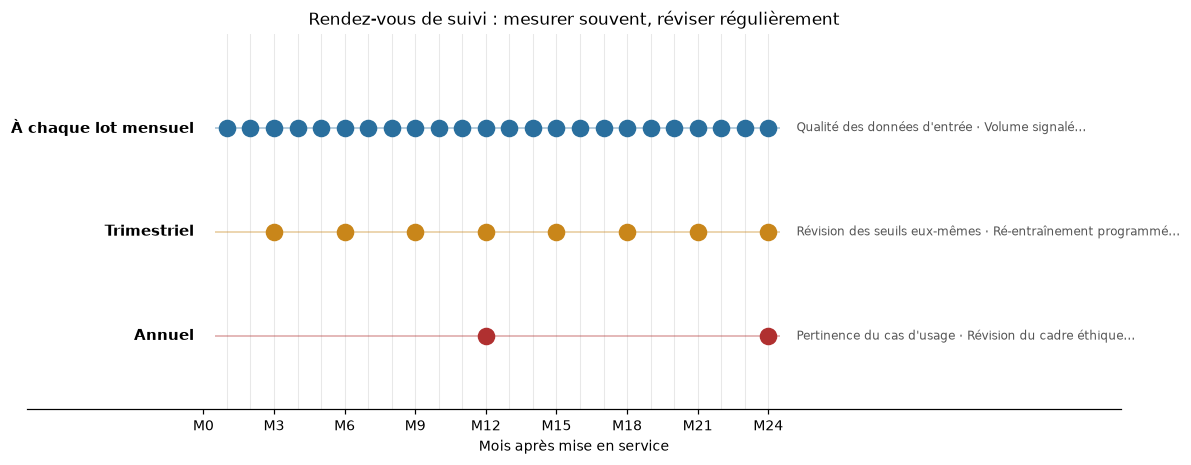

In [32]:
# --- Figure: monitoring review calendar ---------------------------------------------
rendez_vous = [
    ("À chaque lot mensuel", 1, ["Qualité des données d'entrée", "Volume signalé",
                                 "PSI des variables clés", "Performance technique"],
     PALETTE["principal"]),
    ("Trimestriel", 3, ["Révision des seuils eux-mêmes", "Ré-entraînement programmé",
                        "Rétention par segment", "Retours CSM"], PALETTE["attention"]),
    ("Annuel", 12, ["Pertinence du cas d'usage", "Révision du cadre éthique",
                    "Hypothèses de coût métier"], PALETTE["accent"]),
]

fig, ax = plt.subplots(figsize=(11.4, 4.3))
for mois in range(1, 25):
    ax.axvline(mois, color="#e8e8e8", lw=0.7, zorder=0)

for i, (libelle, periode, contenus, couleur) in enumerate(rendez_vous):
    y = len(rendez_vous) - i
    occurrences = [m for m in range(periode, 25, periode)]
    ax.scatter(occurrences, [y] * len(occurrences), s=110, color=couleur, zorder=3)
    ax.hlines(y, 0.5, 24.5, color=couleur, lw=1.1, alpha=0.4)
    ax.text(-0.4, y, libelle, ha="right", va="center", fontsize=9.5, fontweight="bold")
    ax.text(25.2, y, " · ".join(contenus[:2]) + ("…" if len(contenus) > 2 else ""),
            va="center", fontsize=8, color="#555555")

ax.set_xlim(-7.5, 39); ax.set_ylim(0.3, len(rendez_vous) + 0.9)
ax.set_xticks(range(0, 25, 3)); ax.set_xticklabels([f"M{m}" for m in range(0, 25, 3)])
ax.set_yticks([])
ax.set_xlabel("Mois après mise en service")
ax.set_title("Rendez-vous de suivi : mesurer souvent, réviser régulièrement")
for spine in ["left", "right", "top"]:
    ax.spines[spine].set_visible(False)
ax.grid(False)
plt.tight_layout(); plt.show()

### Décision de cadrage n° 3 — cadence de révision

**Décision :** révision **trimestrielle** de la pertinence des indicateurs et de leurs
seuils, alignée sur le cycle de ré-entraînement. Révision **annuelle** du cas d'usage
lui-même et des hypothèses de coût métier.

**Fondement de l'alignement sur le ré-entraînement :** réviser les seuils sans réentraîner
conduirait à juger un modèle inchangé selon des règles changées. Les deux opérations sont
donc couplées.

**Ce que la révision annuelle remet en cause :** la capacité de traitement CSM, l'efficacité
de rétention supposée, le coût d'un contact. Ces trois hypothèses ne sont pas observables
dans les données ; elles vieillissent, et rien ne le signalera automatiquement.

---

# 6. Synthèse du cadrage

## 6.1 Les décisions, et ce qui les fonde

In [33]:
decisions = pd.DataFrame([
    ("Apprentissage supervisé, classification binaire",
     "La colonne `churn` est renseignée sur l'historique", "§ 1.1"),
    ("Cible = churn à l'échéance contractuelle",
     "Seule fenêtre où une action de rétention a un sens", "§ 1.3"),
    ("Objectif de priorisation, non de détection exhaustive",
     "10 % des partants portent ~72 % du revenu perdu", "§ 1.2 · Figure 1"),
    ("Classement par valeur espérée, pas seuil global",
     "Le seuil rationnel varie d'un facteur > 100 selon la valeur", "§ 3.3"),
    ("Capacité CSM traitée comme contrainte de cadrage",
     "Un signalement non traitable ne produit aucune action", "§ 1.3"),
    ("Décision humaine obligatoire",
     "Supervision humaine — lignes directrices UE", "§ 3.1"),
    ("Effet sur les petits comptes compensé par la politique, pas par le modèle",
     "Corriger le score masquerait l'arbitrage au lieu de l'exposer", "§ 3.3"),
    ("Révision trimestrielle des indicateurs, annuelle du cas d'usage",
     "Un dispositif de suivi jamais révisé devient aveugle", "§ 5"),
], columns=["Décision de cadrage", "Fondement", "Renvoi"])
afficher_tableau(decisions, "Décisions de cadrage et fondement de chacune")


Décision de cadrage,Fondement,Renvoi
"Apprentissage supervisé, classification binaire",La colonne `churn` est renseignée sur l'historique,§ 1.1
Cible = churn à l'échéance contractuelle,Seule fenêtre où une action de rétention a un sens,§ 1.3
"Objectif de priorisation, non de détection exhaustive",10 % des partants portent ~72 % du revenu perdu,§ 1.2 · Figure 1
"Classement par valeur espérée, pas seuil global",Le seuil rationnel varie d'un facteur > 100 selon la valeur,§ 3.3
Capacité CSM traitée comme contrainte de cadrage,Un signalement non traitable ne produit aucune action,§ 1.3
Décision humaine obligatoire,Supervision humaine — lignes directrices UE,§ 3.1
"Effet sur les petits comptes compensé par la politique, pas par le modèle",Corriger le score masquerait l'arbitrage au lieu de l'exposer,§ 3.3
"Révision trimestrielle des indicateurs, annuelle du cas d'usage",Un dispositif de suivi jamais révisé devient aveugle,§ 5


In [34]:
hypotheses = pd.DataFrame([
    ("Efficacité de la rétention", "25 %", "15 % – 40 %",
     "Non observable dans les données. Le classement par valeur espérée y est insensible : "
     "facteur commun à tous les comptes, elle ne change pas l'ordre"),
    ("Coût d'un contact CSM", "≈ 135 €", "80 € – 250 €",
     "1,5 h chargée + geste commercial pondéré. Déplace le seuil, pas l'ordre du classement"),
    ("Capacité mensuelle de l'équipe", "≈ 140 comptes", "100 – 200",
     "À confirmer avec le commanditaire. Détermine directement le point de fonctionnement"),
    ("Répartition des échéances", "~12 mois", "—",
     "Le jeu est un instantané sans horodatage. À remplacer par le calendrier réel"),
], columns=["Hypothèse", "Valeur retenue", "Plage de sensibilité", "Statut et conséquence"])
afficher_tableau(hypotheses, "Hypothèses assumées, plages de sensibilité et conséquences")


Hypothèse,Valeur retenue,Plage de sensibilité,Statut et conséquence
Efficacité de la rétention,25 %,15 % – 40 %,"Non observable dans les données. Le classement par valeur espérée y est insensible : facteur commun à tous les comptes, elle ne change pas l'ordre"
Coût d'un contact CSM,≈ 135 €,80 € – 250 €,"1,5 h chargée + geste commercial pondéré. Déplace le seuil, pas l'ordre du classement"
Capacité mensuelle de l'équipe,≈ 140 comptes,100 – 200,À confirmer avec le commanditaire. Détermine directement le point de fonctionnement
Répartition des échéances,~12 mois,—,Le jeu est un instantané sans horodatage. À remplacer par le calendrier réel


## 6.2 Ce qui reste ouvert à l'issue du cadrage

| Point | À qui revient l'arbitrage |
|---|---|
| Capacité mensuelle réelle de l'équipe CSM | Commanditaire |
| Durée de conservation des scores | DPO et commanditaire |
| Pondération entre priorisation par valeur et quota réservé | Commanditaire |
| Existence et modalités du groupe témoin | Commanditaire |

**Aucun de ces points ne bloque la suite du projet**, mais chacun devra être tranché avant
une mise en service réelle. Les laisser ouverts et nommés vaut mieux que de les trancher
unilatéralement depuis l'équipe technique.

---

## 6.3 Correspondance avec le livrable de certification

| Élément de ce carnet | Section du notebook principal | Compétence |
|---|---|---|
| § 1 — Besoin et critères de succès | 2. Cadrage métier | C1 |
| § 2 — Parties prenantes et impacts | 2 et 4 | C1, C2 |
| § 3 — Cadre réglementaire et dilemmes | 4. Enjeux éthiques | C2 |
| § 4 — Critères d'acceptation | 2. Cadrage métier | C1 |
| § 5 — Périodicité de révision | 2. Cadrage, mise en œuvre en 13 | C9 |
| § 6 — Hypothèses et plages de sensibilité | 2 et 9 | C1, C5 |